# Лабораторная работа №2: сравнительное исследование методов оптимизации

Цель: сравнить методы первого, второго и нулевого порядка на гладких,
мультимодальных и разрывных функциях. Отдельно проверяем масштабирование,
multistart, DesmosSurface и `scipy`

## 1. Подготовка окружения

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import optlib
from optlib import functions, experiments, plotting

np.random.seed(7)
plotting.use_notebook_style()
pd.set_option("display.float_format", lambda v: f"{v:.6g}")

FIRST = ["gradient_descent", "heavy_ball", "nesterov", "adam", "rmsprop", "adagrad"]
SECOND = ["newton", "bfgs", "lbfgs"]
ZERO = ["nelder_mead", "powell", "coordinate_search"]
print("методы:", FIRST, "|", SECOND, "|", ZERO)
print("функции:", functions.list_objectives())

методы: ['gradient_descent', 'heavy_ball', 'nesterov', 'adam', 'rmsprop', 'adagrad'] | ['newton', 'bfgs', 'lbfgs'] | ['nelder_mead', 'powell', 'coordinate_search']
функции: ['rosenbrock', 'rastrigin', 'himmelblau', 'ackley', 'beale', 'booth', 'styblinski_tang', 'desmos', 'desmos_surface']


## 2. Галерея тестовых функций

Пять типов ландшафта:

- **Розенброк**: гладкий узкий овраг, минимум $(1,1)$
- **Растригин**: мультимодальная функция, глобальный минимум $(0,0)$
- **Химмельблау**: четыре равных минимума
- **Экли**: плоские области и глубокая центральная воронка
- **DesmosSurface**: модулированный Химмельблау с **разрывами** на границах
  полос (black-box-кейс для методов нулевого порядка)

findfont: Failed to find font weight semibold, now using 700.


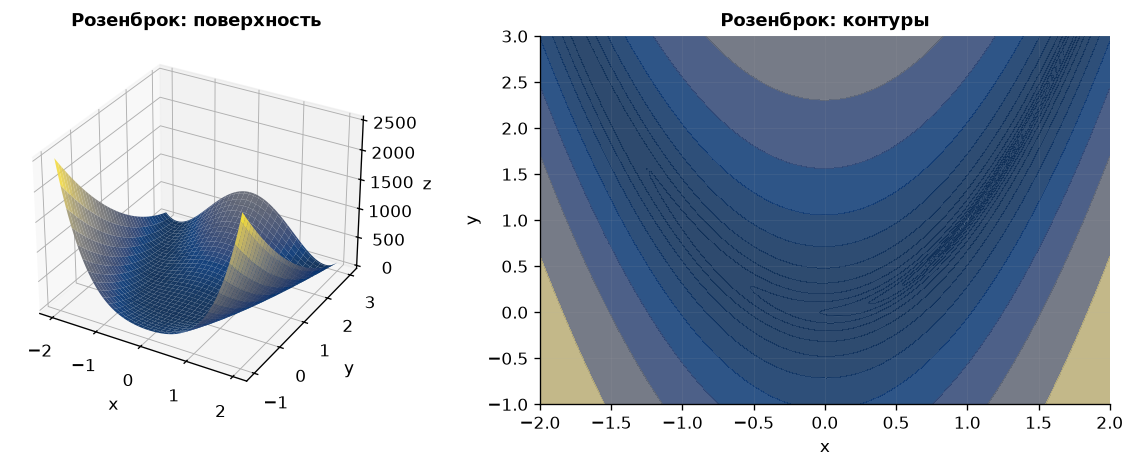

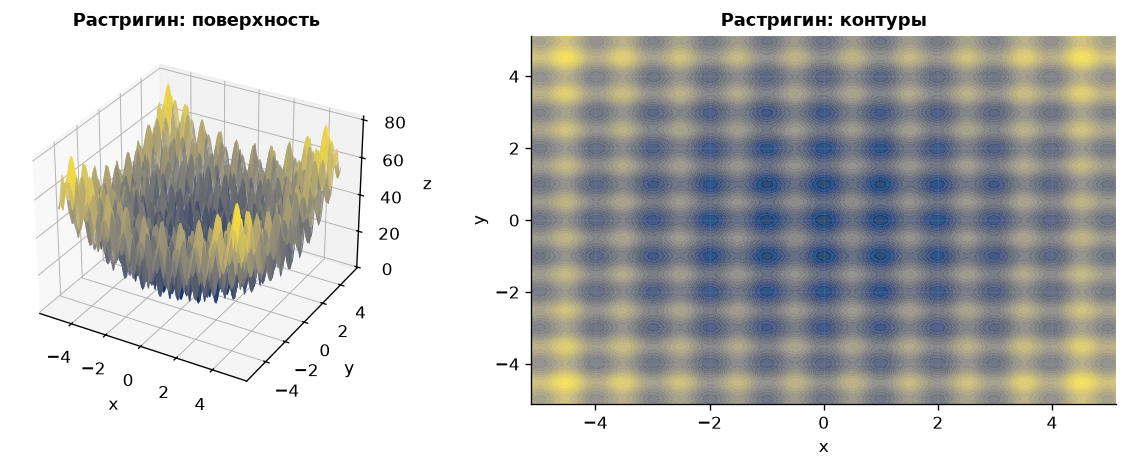

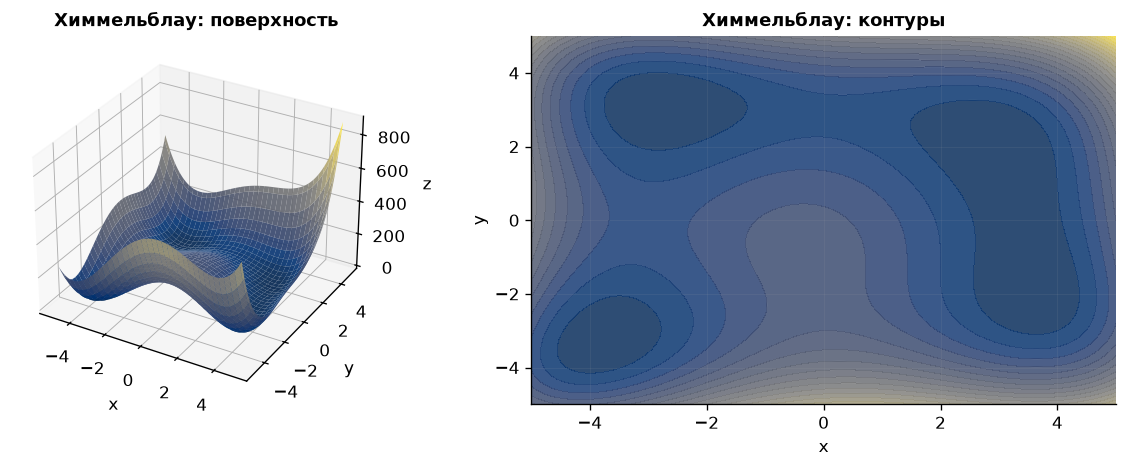

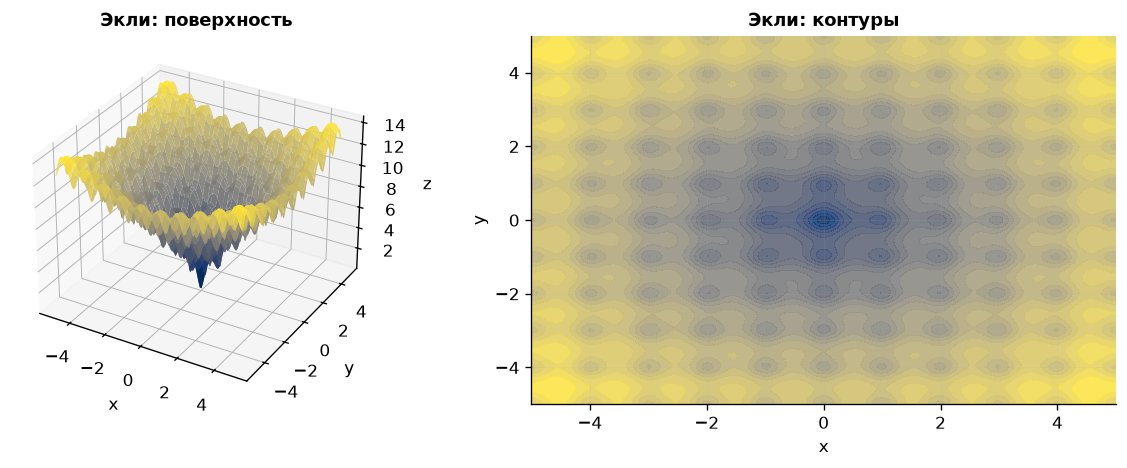

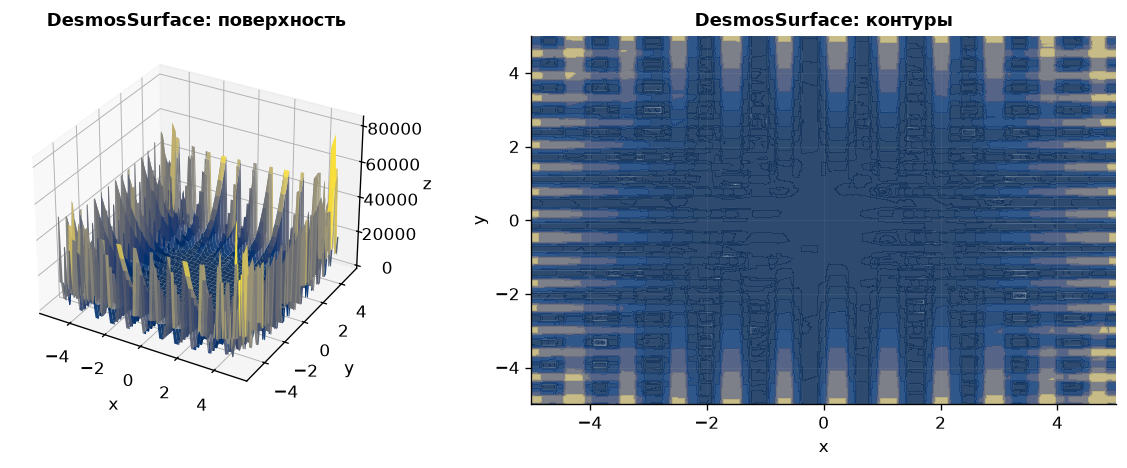

In [2]:
gallery = [
    ("rosenbrock", (-2.0, 2.0), (-1.0, 3.0), "Розенброк"),
    ("rastrigin", (-5.12, 5.12), (-5.12, 5.12), "Растригин"),
    ("himmelblau", (-5.0, 5.0), (-5.0, 5.0), "Химмельблау"),
    ("ackley", (-5.0, 5.0), (-5.0, 5.0), "Экли"),
    ("desmos_surface", (-5.0, 5.0), (-5.0, 5.0), "DesmosSurface"),
]

for name, xlim, ylim, title in gallery:
    obj = functions.get_objective(name, dimension=2)
    fig = plt.figure(figsize=(10.4, 4.0))
    plotting.plot_surface3d(
        fig,
        obj.value,
        x_limits=xlim,
        y_limits=ylim,
        points=110,
        title=f"{title}: поверхность",
        position=121,
    )
    ax2 = fig.add_subplot(122)
    plotting.plot_contours(
        ax2,
        obj.value,
        x_limits=xlim,
        y_limits=ylim,
        points=150,
        title=f"{title}: контуры",
        log_levels=(name in {"rosenbrock", "desmos_surface"}),
    )
    plt.show()

**Вывод.** Розенброк проверяет кривизну, Растригин: локальные минимумы,
Ackley: масштаб шага, DesmosSurface: отказ от градиента

## 3. Сравнение классов методов на Розенброке и Растригине (2D)

Сравниваем классы методов по траектории, сходимости и таблице: $f^*$, итерации,
вызовы функции и время

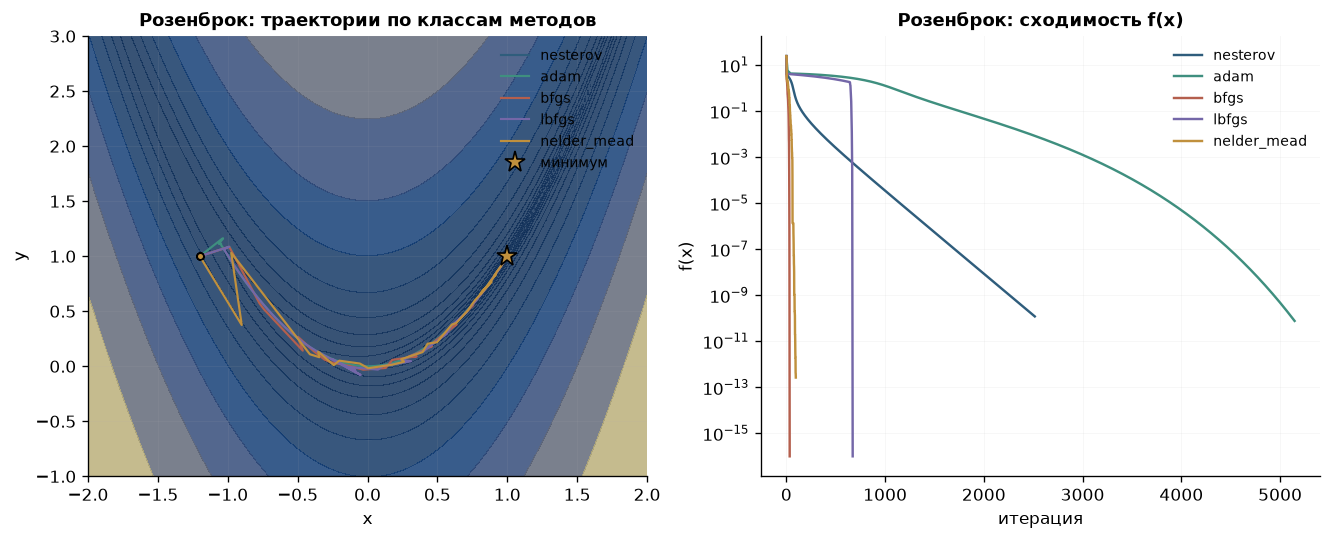

In [3]:
def run_subset(obj, x0, specs):
    # specs: dict вида {метод: kwargs}; возвращает {метод: результат}.
    return {m: experiments.run_method(obj, x0, m, **kw) for m, kw in specs.items()}


# Розенброк: по одному яркому представителю каждого класса.
rosen = functions.get_objective("rosenbrock", dimension=2)
r_x0 = np.array([-1.2, 1.0])
rosen_specs = {
    "nesterov": dict(learning_rate=1e-3, max_iter=20000, momentum=0.9),
    "adam": dict(learning_rate=1e-2, max_iter=20000),
    "bfgs": dict(max_iter=2000),
    "lbfgs": dict(max_iter=2000),
    "nelder_mead": dict(max_iter=2000),
}
rosen_results = run_subset(rosen, r_x0, rosen_specs)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))
plotting.plot_trajectories(
    axes[0],
    rosen.value,
    rosen_results,
    x_limits=(-2.0, 2.0),
    y_limits=(-1.0, 3.0),
    minimum=[1.0, 1.0],
    title="Розенброк: траектории по классам методов",
)
plotting.plot_convergence(axes[1], rosen_results, key="f", title="Розенброк: сходимость f(x)")
plt.show()

In [4]:
# Полная сводная таблица по всем методам всех классов (Розенброк).
all_methods = FIRST + SECOND + ZERO
rosen_rows = experiments.compare_methods(rosen, r_x0, all_methods, max_iter=20000)
rosen_table = pd.DataFrame(rosen_rows)[
    [
        "method",
        "value",
        "iterations",
        "function_evaluations",
        "gradient_evaluations",
        "wall_ms",
        "converged",
        "distance_to_minimum",
    ]
]
rosen_table.columns = [
    "метод",
    "f*",
    "итер.",
    "выз. f",
    "выз. ∇f",
    "время, мс",
    "сошёлся",
    "‖x*−x_min‖",
]
rosen_table.round(6)

,метод,f*,итер.,выз. f,выз. ∇f,"время, мс",сошёлся,‖x*−x_min‖
0,gradient_descent,0,20000,20001,20001,3.0042,False,0.000312
1,heavy_ball,0,2472,2473,2473,0.4036,True,2.4e-05
2,nesterov,0,2516,2517,5033,0.6822,True,2.4e-05
3,adam,0,12326,12327,12327,3.9472,True,2.1e-05
4,rmsprop,0.000229,20000,20001,20001,3.0486,False,0.000685
5,adagrad,4.25653,20000,20001,20001,2.9014,False,2.06728
6,newton,0,21,22,22,0.0533,True,0
7,bfgs,0,34,35,35,0.0419,True,0
8,lbfgs,0,672,673,673,0.4055,True,0
9,nelder_mead,0,96,185,0,0.104,True,1e-06


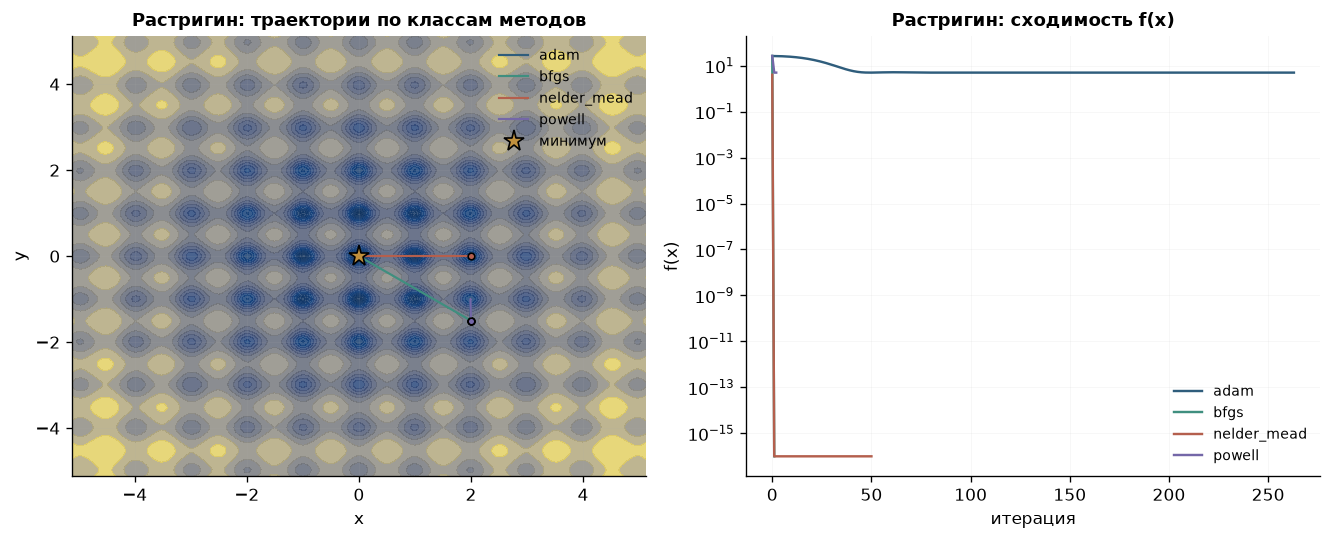

,метод,f*,итер.,"время, мс",сошёлся,‖x*−x_min‖
0,gradient_descent,4.97479,43,0.2161,True,2.22479
1,heavy_ball,4.97479,265,0.3708,True,2.22479
2,nesterov,4.97479,55,0.0688,True,2.22479
3,adam,4.97479,1166,0.6262,True,2.22479
4,rmsprop,4.97479,360,0.1644,True,2.22479
5,adagrad,21.9281,3000,1.0942,False,2.40726
6,newton,26.2413,2,0.0625,True,2.49654
7,bfgs,0,1,0.0289,True,0
8,lbfgs,0,1,0.0268,True,0
9,nelder_mead,0,50,0.0678,True,0


In [5]:
# Растригин: мультимодальный. Старт рядом, но не в глобальном минимуме.
rastrigin = functions.get_objective("rastrigin", dimension=2)
ra_x0 = np.array([2.0, -1.5])
rastrigin_specs = {
    "adam": dict(learning_rate=1e-2, max_iter=3000),
    "bfgs": dict(max_iter=2000),
    "nelder_mead": dict(max_iter=2000),
    "powell": dict(max_iter=2000),
}
rastrigin_results = run_subset(rastrigin, ra_x0, rastrigin_specs)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))
plotting.plot_trajectories(
    axes[0],
    rastrigin.value,
    rastrigin_results,
    x_limits=(-5.12, 5.12),
    y_limits=(-5.12, 5.12),
    minimum=[0.0, 0.0],
    title="Растригин: траектории по классам методов",
)
plotting.plot_convergence(axes[1], rastrigin_results, key="f", title="Растригин: сходимость f(x)")
plt.show()

rastrigin_rows = experiments.compare_methods(rastrigin, ra_x0, all_methods, max_iter=3000)
rastrigin_table = pd.DataFrame(rastrigin_rows)[
    ["method", "value", "iterations", "wall_ms", "converged", "distance_to_minimum"]
]
rastrigin_table.columns = ["метод", "f*", "итер.", "время, мс", "сошёлся", "‖x*−x_min‖"]
rastrigin_table.round(6)

**Вывод.** На Розенброке BFGS/L-BFGS резко сокращают число итераций. На
Растригине один старт не гарантирует глобальный минимум, нужен multistart

### 3.1. Матрица `method × function × dimension`

Компактный срез: `adam`, `lbfgs`, `nelder_mead` × Rosenbrock/Rastrigin/Ackley ×
размерности `2/10/50`

In [6]:
def start_for(function_name: str, n: int) -> np.ndarray:
    if function_name == "rosenbrock":
        x = np.full(n, -1.2)
        x[1::2] = 1.0
        return x
    if function_name == "rastrigin":
        return np.linspace(2.0, -1.5, n)
    return np.full(n, 2.5)


matrix_methods = {
    "adam": dict(learning_rate=1e-2, max_iter=2500),
    "lbfgs": dict(max_iter=1000),
    "nelder_mead": dict(max_iter=600),
}
matrix_functions = ("rosenbrock", "rastrigin", "ackley")
matrix_dims = (2, 10, 50)

matrix_rows = []
for function_name in matrix_functions:
    for n in matrix_dims:
        obj = functions.get_objective(function_name, dimension=n)
        start = start_for(function_name, n)
        for method, kwargs in matrix_methods.items():
            try:
                res = experiments.run_method(
                    obj,
                    start,
                    method,
                    gradient_tolerance=1e-5,
                    log_trajectory=False,
                    **kwargs,
                )
                matrix_rows.append(
                    {
                        "function": function_name,
                        "n": n,
                        "method": method,
                        "f*": res["value"],
                        "iterations": res["iterations"],
                        "calls_f": res.get("function_evaluations", 0),
                        "converged": res["converged"],
                    }
                )
            except ValueError as exc:
                matrix_rows.append(
                    {
                        "function": function_name,
                        "n": n,
                        "method": method,
                        "f*": np.nan,
                        "iterations": np.nan,
                        "calls_f": np.nan,
                        "converged": False,
                        "note": str(exc),
                    }
                )

matrix = pd.DataFrame(matrix_rows)
display(
    matrix.pivot_table(index=["function", "n"], columns="method", values="f*")
    .style.format("{:.4g}")
    .background_gradient(cmap="viridis_r", axis=None)
)
matrix[["function", "n", "method", "f*", "iterations", "calls_f", "converged"]].round(6)

,function,n,method,f*,iterations,calls_f,converged
0,rosenbrock,2,adam,0.008814,2500,2501,False
1,rosenbrock,2,lbfgs,0,672,673,True
2,rosenbrock,2,nelder_mead,0,96,185,True
3,rosenbrock,10,adam,6.58162,2500,2501,False
4,rosenbrock,10,lbfgs,0,70,71,True
5,rosenbrock,10,nelder_mead,9.17606,600,862,False
6,rosenbrock,50,adam,46.1775,2500,2501,False
7,rosenbrock,50,lbfgs,0,279,280,True
8,rosenbrock,50,nelder_mead,1058.32,600,758,False
9,rastrigin,2,adam,4.97479,263,264,True


**Вывод.** L-BFGS лучше масштабируется на гладких задачах. Nelder-Mead полезен
как black-box baseline, но быстро дорожает с ростом размерности

## 4. Кейс DesmosSurface: разрывная функция и методы нулевого порядка

Формула из контракта:

$$
z=d\left(\left([x(\operatorname{round}(\sin(10y))+2)]^2+y-10\right)^2
+\left(x+[y(\operatorname{round}(\sin(7x))+2)]^2-7\right)^2\right)
$$

Из-за `round(sin(t))` поверхность разрывна на границах полос. Градиентные
методы отклоняются; честный выбор: Nelder-Mead, Powell, coordinate search

Запуск adam на DesmosSurface отклонён:
    desmos_surface does not provide a gradient for first-order optimization


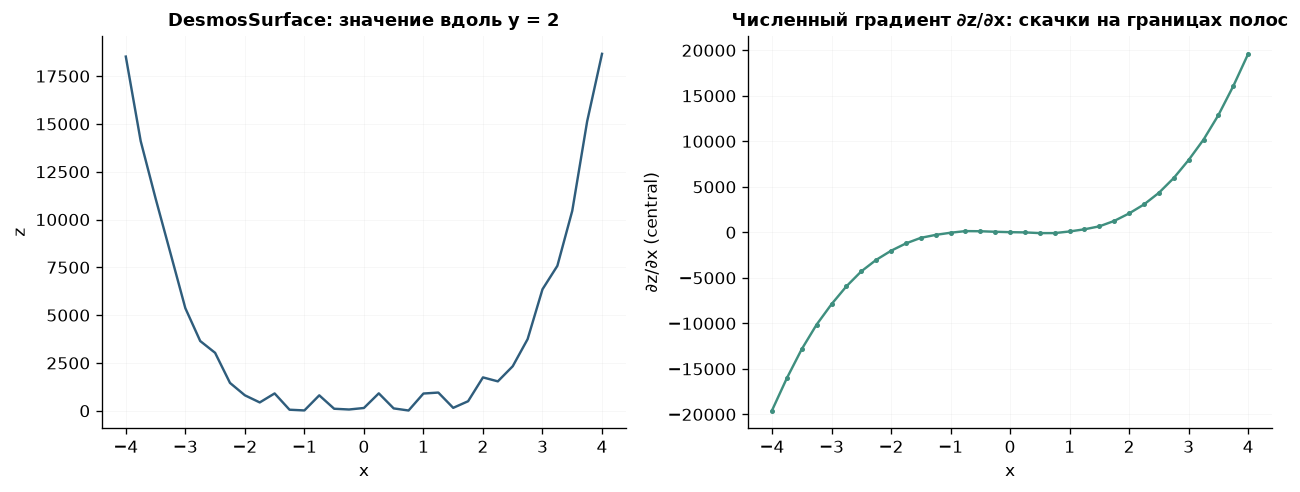

In [7]:
desmos = functions.get_objective("desmos_surface", dimension=2)

# (а) Градиентный метод на разрывной функции -> отклоняется.
try:
    experiments.run_method(desmos, np.array([3.0, 2.0]), "adam", learning_rate=1e-3, max_iter=100)
except ValueError as exc:
    print("Запуск adam на DesmosSurface отклонён:")
    print("   ", exc)

# (б) Шум численного градиента вдоль среза y = 2: значение растёт гладко,
#     а численный градиент скачет на границах полос.
xs = np.linspace(-4.0, 4.0, 33)
vals = np.array([desmos.value(np.array([x, 2.0])) for x in xs])
grad_x = np.array(
    [functions.desmos_numerical_gradient(np.array([x, 2.0]), scheme="central")[0] for x in xs]
)

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.2))
axes[0].plot(xs, vals, color=plotting.PALETTE[0])
axes[0].set_title("DesmosSurface: значение вдоль y = 2")
axes[0].set_xlabel("x")
axes[0].set_ylabel("z")
axes[1].plot(xs, grad_x, color=plotting.PALETTE[1], marker=".")
axes[1].set_title("Численный градиент ∂z/∂x: скачки на границах полос")
axes[1].set_xlabel("x")
axes[1].set_ylabel("∂z/∂x (central)")
plt.show()

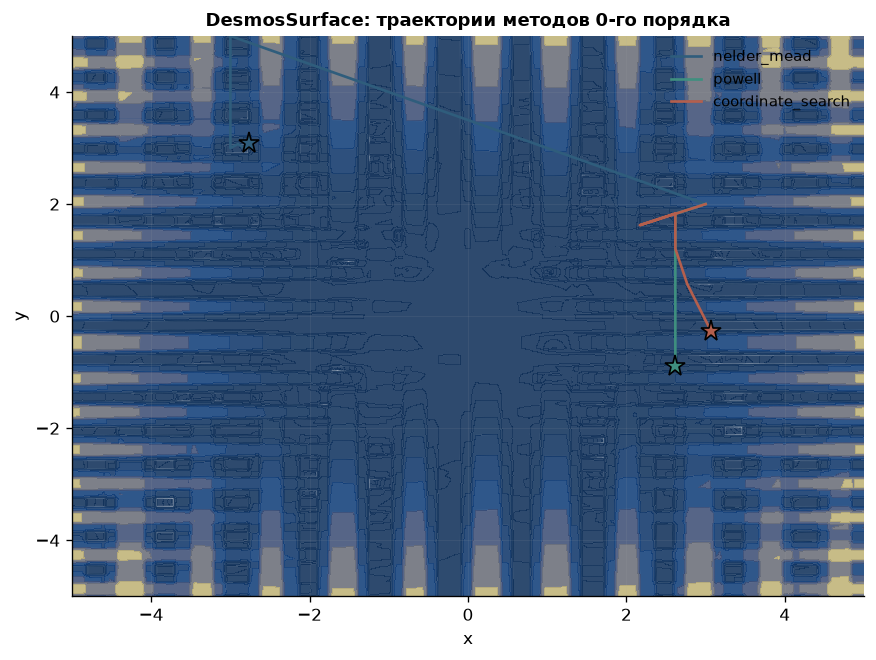

,метод,f*,итераций,вызовов f,сошёлся
0,nelder_mead,0.611,165,332,True
1,powell,29.177,6,595,True
2,coordinate_search,11.732,3000,198001,False


In [8]:
# (в) Методы нулевого порядка на DesmosSurface из x0 = (3, 2).
d_x0 = np.array([3.0, 2.0])
desmos_results = {m: experiments.run_method(desmos, d_x0, m, max_iter=3000) for m in ZERO}

fig, ax = plt.subplots(figsize=(7.4, 5.6))
plotting.plot_contours(
    ax,
    desmos.value,
    x_limits=(-5.0, 5.0),
    y_limits=(-5.0, 5.0),
    points=150,
    title="DesmosSurface: траектории методов 0-го порядка",
    log_levels=True,
)
for idx, (name, res) in enumerate(desmos_results.items()):
    path = np.asarray(res["trajectory"]["x"])
    ax.plot(path[:, 0], path[:, 1], lw=1.6, color=plotting.PALETTE[idx], label=name)
    ax.plot(path[-1, 0], path[-1, 1], "*", ms=13, color=plotting.PALETTE[idx], mec="black")
ax.legend(loc="upper right", fontsize=9)
plt.show()

desmos_rows = [experiments.result_summary(m, r, desmos) for m, r in desmos_results.items()]
desmos_table = pd.DataFrame(desmos_rows)[
    ["method", "value", "iterations", "function_evaluations", "converged"]
]
desmos_table.columns = ["метод", "f*", "итераций", "вызовов f", "сошёлся"]
desmos_table.round(4)

**Вывод.** Численный градиент скачет на границах полос. Nelder-Mead из
$x_0=(3,2)$ даёт лучший результат ($f^*\approx0.6$); остальные 0-order методы
могут застревать в соседних полосах

## 5. Масштабирование по размерности ($n = 2, 10, 50, 100$)

Проверяем Rosenbrock ND до $n=100$. Главное сравнение: BFGS, L-BFGS и Adam

In [9]:
def make_start(n: int) -> np.ndarray:
    x = np.full(n, -1.2)
    x[1::2] = 1.0
    return x


scale_specs = {
    "lbfgs": dict(max_iter=5000),
    "bfgs": dict(max_iter=5000),
    "adam": dict(learning_rate=1e-3, max_iter=20000),
}
dims = [2, 10, 50, 100]

scale_rows = []
for n in dims:
    obj = functions.get_objective("rosenbrock", dimension=n)
    start = make_start(n)
    for method, kw in scale_specs.items():
        res = experiments.run_method(obj, start, method, gradient_tolerance=1e-6, **kw)
        wall = (
            float(res["trajectory"]["time_ms"][-1]) if len(res["trajectory"]["time_ms"]) else np.nan
        )
        scale_rows.append(
            {
                "n": n,
                "метод": method,
                "итераций": res["iterations"],
                "время, мс": wall,
                "f*": res["value"],
                "сошёлся": res["converged"],
            }
        )
scale_table = pd.DataFrame(scale_rows)
scale_table.round(6)

,n,метод,итераций,"время, мс",f*,сошёлся
0,2,lbfgs,672,0.4072,0,True
1,2,bfgs,34,0.0151,0,True
2,2,adam,12326,3.2802,0,True
3,10,lbfgs,72,0.1127,0,True
4,10,bfgs,81,0.0855,0,True
5,10,adam,15301,14.5366,0,True
6,50,lbfgs,282,0.7825,0,True
7,50,bfgs,262,2.5685,0,True
8,50,adam,17642,68.4766,0,True
9,100,lbfgs,532,2.4579,0,True


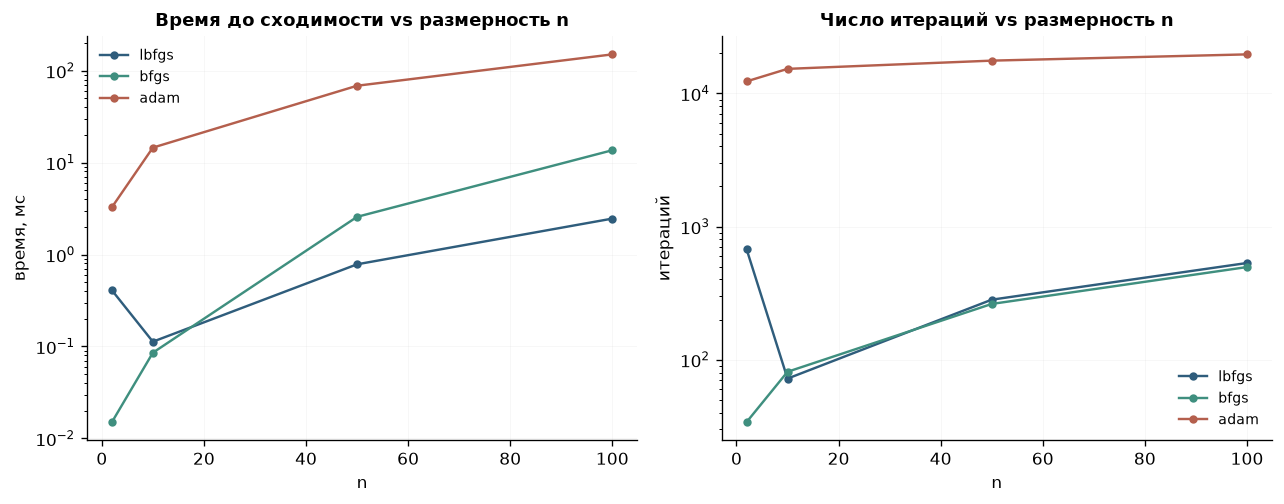

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.3))
for idx, method in enumerate(scale_specs):
    sub = scale_table[scale_table["метод"] == method]
    axes[0].plot(sub["n"], sub["время, мс"], "o-", color=plotting.PALETTE[idx], label=method)
    axes[1].plot(sub["n"], sub["итераций"], "o-", color=plotting.PALETTE[idx], label=method)
axes[0].set_title("Время до сходимости vs размерность n")
axes[0].set_xlabel("n")
axes[0].set_ylabel("время, мс")
axes[0].set_yscale("log")
axes[0].legend()
axes[1].set_title("Число итераций vs размерность n")
axes[1].set_xlabel("n")
axes[1].set_ylabel("итераций")
axes[1].set_yscale("log")
axes[1].legend()
plt.show()

**Вывод.** L-BFGS сохраняет качество BFGS при меньшей памяти и лучшем времени;
Adam требует на порядки больше итераций

## 6. Робастность на мультимодальной функции (multistart, Растригин)

12 случайных стартов на Rastrigin 2D. Метрика робастности: распределение
финального $f^*$ и число попаданий в область $f^*<1$

In [11]:
np.random.seed(2024)
starts = np.random.uniform(-5.12, 5.12, size=(12, 2))
multistart_methods = ["adam", "bfgs", "nelder_mead", "powell"]
ms_rows = experiments.multistart_compare(
    rastrigin, multistart_methods, starts=starts, max_iter=3000
)
ms_df = pd.DataFrame(ms_rows)

# Сводка по методам: лучший / медианный / худший f* и доля «успехов» (f* < 1).
summary = (
    ms_df.groupby("method")["value"]
    .agg(минимум="min", медиана="median", максимум="max")
    .reset_index()
)
summary["успехов (f*<1)"] = [
    int((ms_df[ms_df["method"] == m]["value"] < 1.0).sum()) for m in summary["method"]
]
summary.columns = ["метод", "лучший f*", "медиана f*", "худший f*", "успехов из 12"]
summary.round(4)

,метод,лучший f*,медиана f*,худший f*,успехов из 12
0,adam,0.995,14.9243,33.8283,1
1,bfgs,4.9748,14.9243,36.813,0
2,nelder_mead,0,0.995,8.3062,10
3,powell,0.995,14.9243,33.8283,1


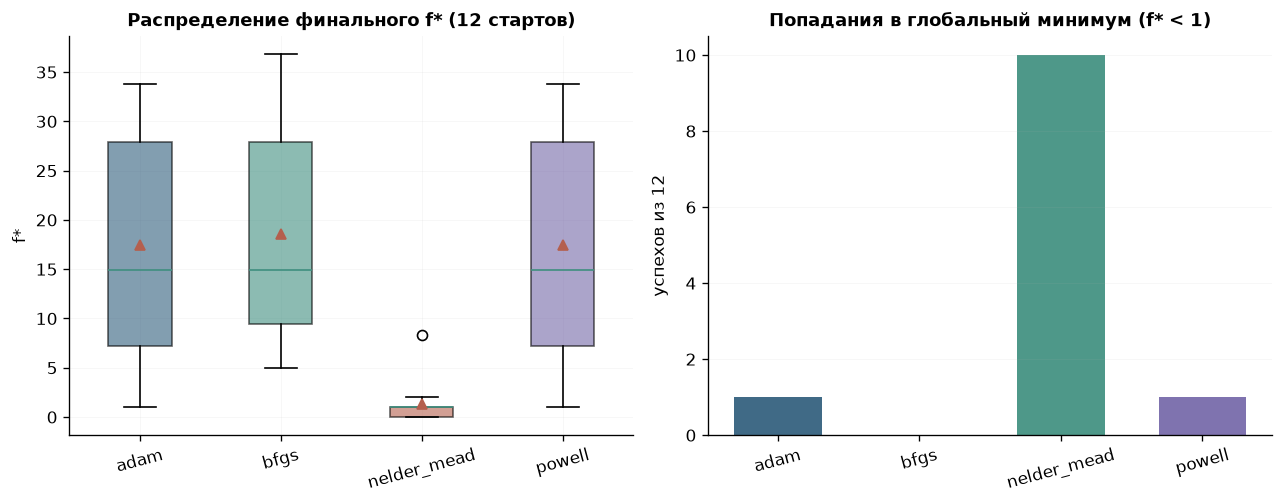

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.3))

# (а) Boxplot распределения f* по методам.
data = [ms_df[ms_df["method"] == m]["value"].to_numpy() for m in multistart_methods]
bp = axes[0].boxplot(data, tick_labels=multistart_methods, patch_artist=True, showmeans=True)
for patch, color in zip(bp["boxes"], plotting.PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_title("Распределение финального f* (12 стартов)")
axes[0].set_ylabel("f*")
axes[0].tick_params(axis="x", rotation=15)

# (б) Доля успешных стартов.
success = [int((ms_df[ms_df["method"] == m]["value"] < 1.0).sum()) for m in multistart_methods]
plotting.bar_comparison(
    axes[1],
    multistart_methods,
    success,
    ylabel="успехов из 12",
    title="Попадания в глобальный минимум (f* < 1)",
)
axes[1].tick_params(axis="x", rotation=15)
plt.show()

**Вывод.** На мультимодальной функции результат зависит от старта. Multistart
обязателен; Nelder-Mead здесь оказался самым робастным baseline

## 7. Чувствительность к `learning_rate` и схеме градиента

Два чувствительных места first-order методов: `learning_rate` и источник
градиента. Проверяем GD по `lr` и Adam по `forward/central/five_point/autograd`

In [13]:
lr_rows = []
for lr in (1e-4, 3e-4, 1e-3, 3e-3, 1e-2):
    res = experiments.run_method(
        rosen,
        r_x0,
        "gradient_descent",
        learning_rate=lr,
        max_iter=5000,
        gradient_tolerance=1e-6,
        log_trajectory=False,
    )
    lr_rows.append(
        {
            "lr": lr,
            "f*": res["value"],
            "iterations": res["iterations"],
            "converged": res["converged"],
        }
    )

scheme_rows = []
gradient_sources = {
    "forward": lambda x: optlib.RosenbrockNumericalGradient(x, scheme="forward"),
    "central": lambda x: optlib.RosenbrockNumericalGradient(x, scheme="central"),
    "five_point": lambda x: optlib.RosenbrockNumericalGradient(x, scheme="five_point"),
    "autograd": optlib.RosenbrockAutogradGradient,
}
for scheme, gradient in gradient_sources.items():
    res = optlib.Minimize(
        rosen.value,
        gradient,
        r_x0,
        method="adam",
        learning_rate=1e-2,
        max_iter=3000,
        gradient_tolerance=1e-6,
        step_tolerance=0.0,
        function_tolerance=0.0,
        log_trajectory=False,
    )
    scheme_rows.append(
        {
            "gradient": scheme,
            "f*": res["value"],
            "iterations": res["iterations"],
            "grad_norm": res["gradient_norm"],
            "converged": res["converged"],
        }
    )

lr_table = pd.DataFrame(lr_rows)
scheme_table = pd.DataFrame(scheme_rows)
display(lr_table.round(8))
display(scheme_table.round(8))

,lr,f*,iterations,converged
0,0.0001,2.30572,5000,False
1,0.0003,0.162181,5000,False
2,0.001,0.00376092,5000,False
3,0.003,0.326592,5000,False
4,0.01,NaN,5000,False


,gradient,f*,iterations,grad_norm,converged
0,forward,0.00124868,3000,0.0353482,False
1,central,0.00124845,3000,0.035349,False
2,five_point,0.00124845,3000,0.035349,False
3,autograd,0.00124845,3000,0.035349,False


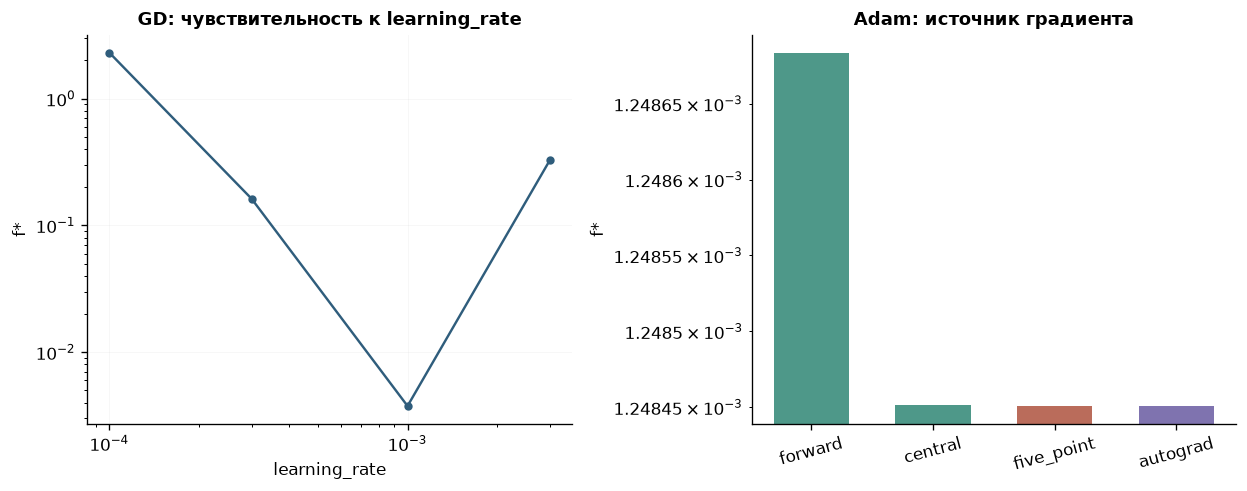

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].plot(lr_table["lr"], lr_table["f*"], "o-", color=plotting.PALETTE[0])
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("learning_rate")
axes[0].set_ylabel("f*")
axes[0].set_title("GD: чувствительность к learning_rate")

plotting.bar_comparison(
    axes[1],
    list(scheme_table["gradient"]),
    list(scheme_table["f*"] + 1e-16),
    ylabel="f*",
    title="Adam: источник градиента",
)
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", rotation=15)
plt.show()

**Вывод.** Малый `lr` слишком медленный, большой нестабилен. `autograd` и
центральные схемы точнее forward; five-point дороже по вычислениям

## 8. Сравнение с эталоном `scipy.optimize`

Сравниваем наши реализации с `scipy.optimize` на Rosenbrock 2D

In [15]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scipy_rows = []
    for method in ("CG", "BFGS", "L-BFGS-B", "Newton-CG", "Nelder-Mead", "Powell"):
        row = experiments.scipy_minimize(rosen, r_x0, method=method, max_iter=20000)
        if row is not None:
            scipy_rows.append(row)

# Наши реализации тех же классов.
ours_methods = ["bfgs", "lbfgs", "newton", "nelder_mead", "powell"]
ours_rows = experiments.compare_methods(rosen, r_x0, ours_methods, max_iter=20000)

compare = pd.DataFrame(ours_rows + scipy_rows)[
    ["method", "value", "iterations", "function_evaluations", "gradient_evaluations", "converged"]
]
compare.columns = ["метод", "f*", "итераций", "выз. f", "выз. ∇f", "сошёлся"]
compare.round(10)

,метод,f*,итераций,выз. f,выз. ∇f,сошёлся
0,bfgs,0,34,35,35,True
1,lbfgs,0,672,673,673,True
2,newton,0,21,22,22,True
3,nelder_mead,0,96,185,0,True
4,powell,0,429,42472,0,True
5,scipy:CG,0,36,78,77,True
6,scipy:BFGS,0,32,39,39,True
7,scipy:L-BFGS-B,0,36,44,44,True
8,scipy:Newton-CG,3e-10,83,105,105,True
9,scipy:Nelder-Mead,8e-10,85,159,0,True


**Вывод.** `optlib` воспроизводит качество `scipy` ($f^*\to0$) для second-order
и zero-order методов

## Выводы

1. Second-order методы выигрывают на гладких задачах за счёт кривизны
2. Zero-order методы нужны для black-box и разрывных функций
3. Multistart обязателен на мультимодальных ландшафтах
4. L-BFGS масштабируется лучше BFGS до $n=100$
5. `optlib` совпадает с `scipy` по качеству на эталонных задачах